# **Stock Price Prediction with LSTM (PyTorch)**

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  #This line picks which hardware your code should run the neural network on: your graphics card (GPU) if you have one, otherwise your regular processor (CPU).

In [5]:
device


device(type='cpu')

# 1.Pulling Data

 uses the yfinance library to download Apple's historical price data starting from January 1, 2020, up to today (since no end date was given).

In [195]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [9]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271545,72.331702,71.029923,71.282575,135480400
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800
2020-01-06,72.139206,72.177707,70.442807,70.693058,118387200
2020-01-07,71.799927,72.403889,71.580958,72.148828,108872000
2020-01-08,72.954903,73.255683,71.503938,71.503938,132079200
...,...,...,...,...,...
2026-08-31,316.850006,321.239990,312.799988,319.600006,41242700
2026-09-01,325.130005,327.299988,314.730011,316.980011,53167400


### **Note**  --> We use the Close price since it's the standard, most stable reference point for a stock's daily value — it reflects the price after a full day of trading, unlike Open/High/Low which are just single moments during the day.

# 2.Exploratory Stock Analysis

Before building the prediction model, we'll explore the data across several tech stocks (AAPL, GOOG, MSFT, AMZN) to understand price trends, volatility, and relationships between stocks.

In [193]:
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')

tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

end = datetime.now()
start = datetime(end.year - 3, end.month, end.day)

company_data = {}
for stock in tech_list:
    df_temp = yf.download(stock, start, end)
    if isinstance(df_temp.columns, pd.MultiIndex):
        df_temp.columns = df_temp.columns.get_level_values(0)  # flatten to just Close/High/Low/Open/Volume
    company_data[stock] = df_temp

company_list = [company_data[t] for t in tech_list]
for company, name in zip(company_list, company_name):
    company["company_name"] = name

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 1. Closing Price Over Time

Plot each stock's closing price history in its own subplot, to visually compare general long-term trends across companies.

- `plt.subplot(2, 2, i)`: arranges the 4 charts in a 2x2 grid, one per stock
- `company['Close'].plot()`: plots the daily closing price as a line

Comparing all 4 side-by-side shows which stocks trended up, down, or stayed flat over the period.

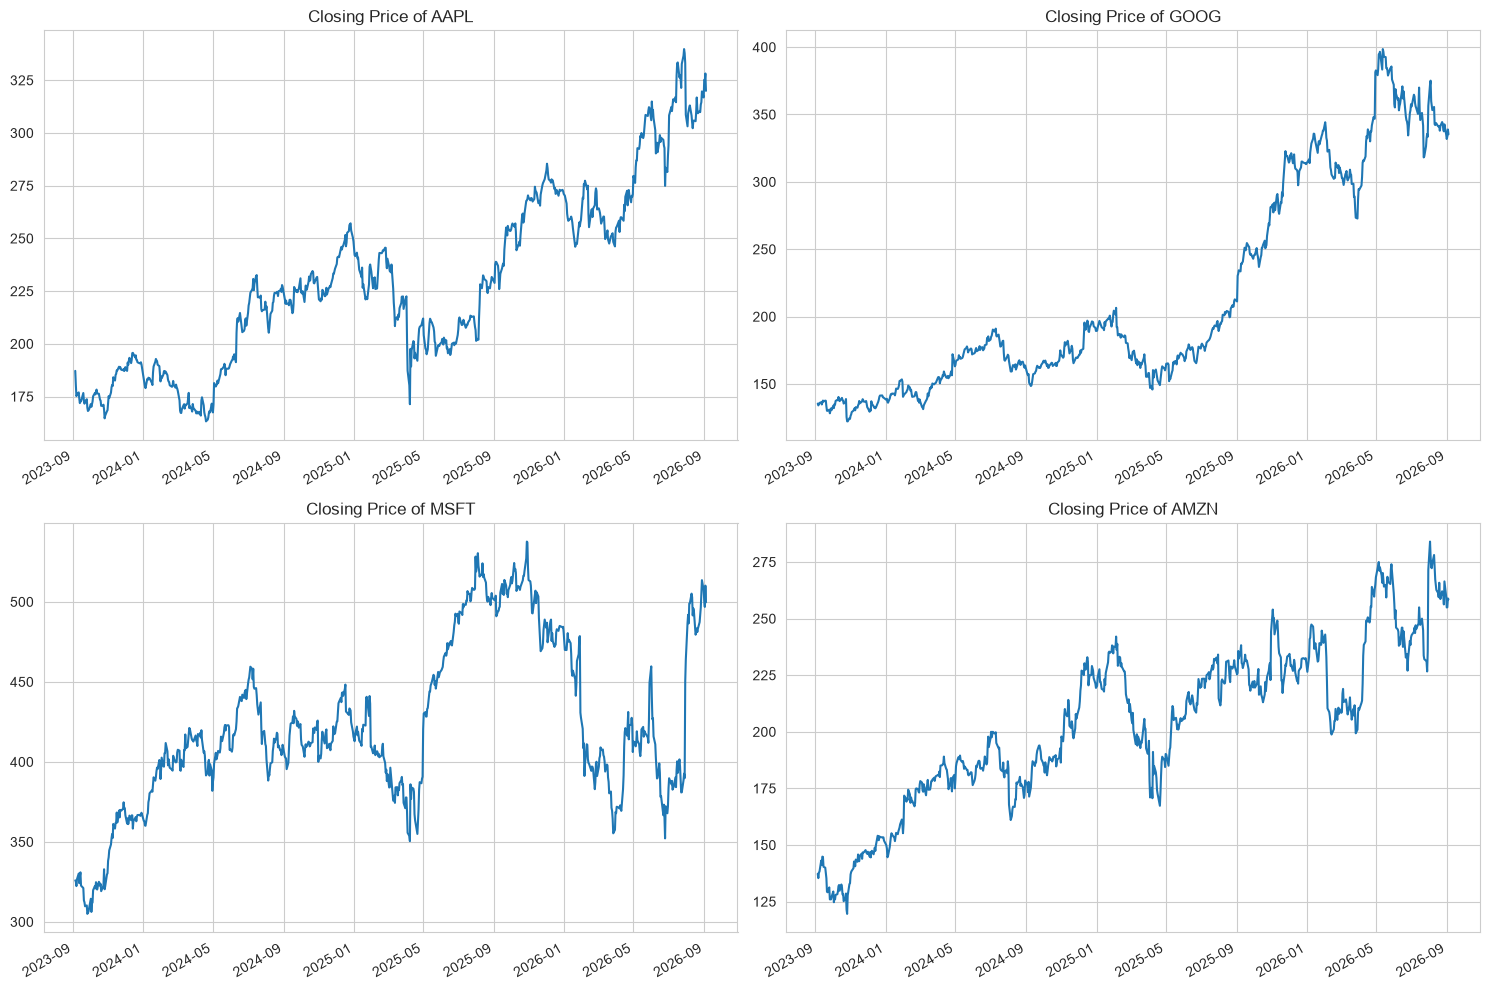

In [197]:
plt.figure(figsize=(15, 10))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Close'].plot()
    plt.title(f"Closing Price of {tech_list[i-1]}")
    plt.xlabel(None)
plt.tight_layout()
plt.show()

## 2. Trading Volume Over Time

Plot each stock's daily trading volume, showing how much of each stock was bought and sold each day.

- Same 2x2 layout as the closing price chart, but plotting `Volume` instead of `Close`

Spikes in volume often line up with major news, earnings reports, or market-wide events — useful context for interpreting price moves.

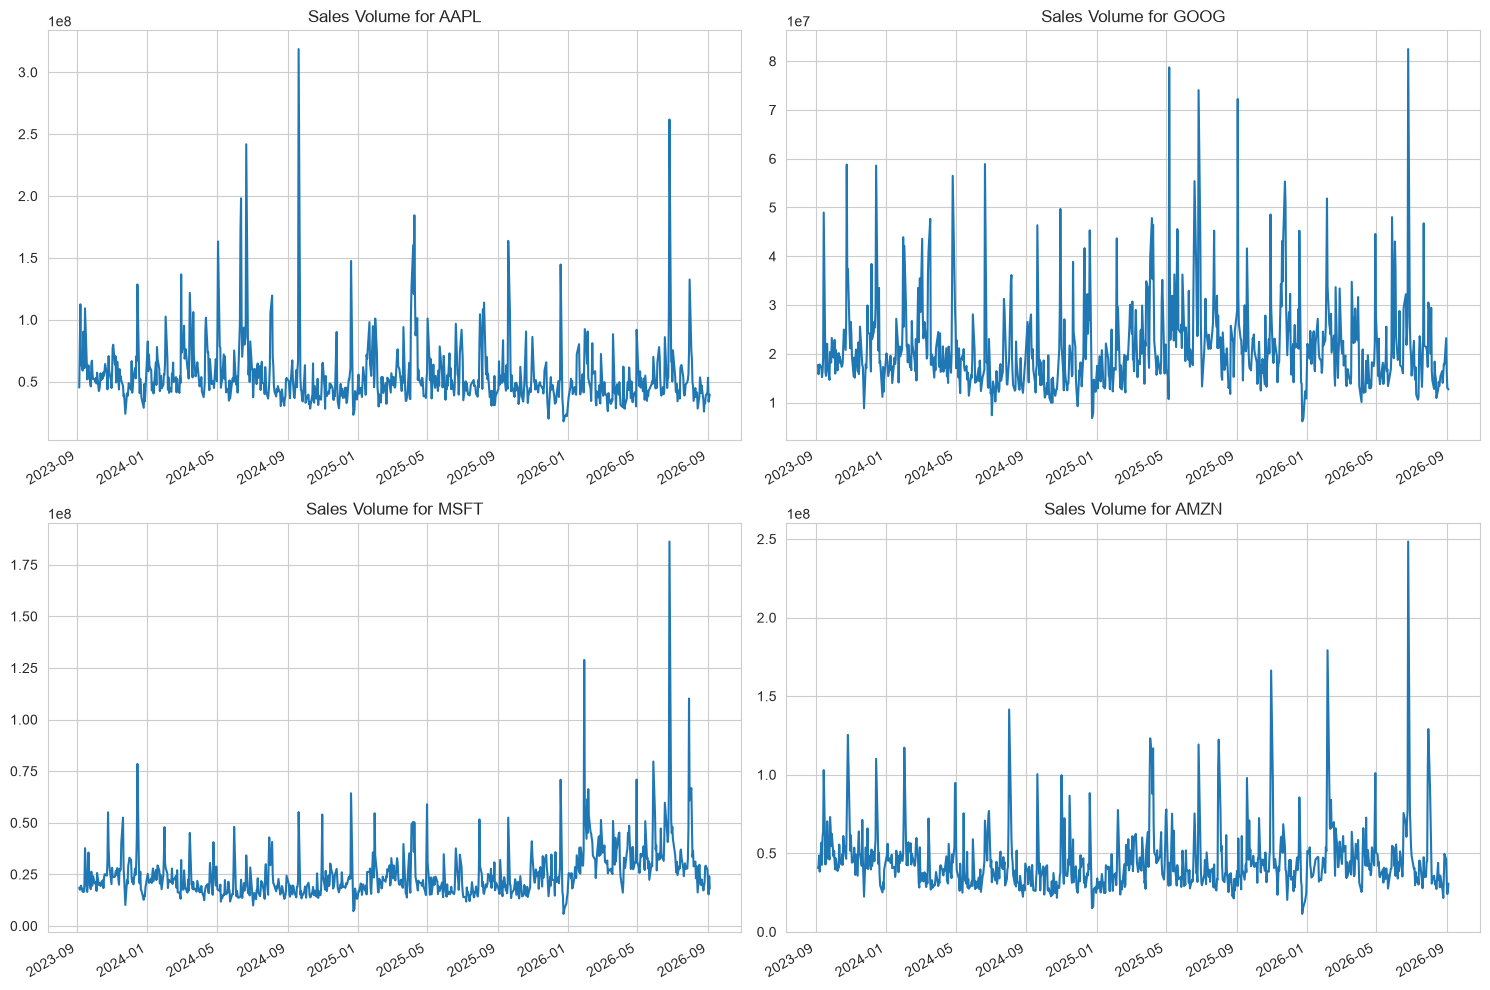

In [199]:
plt.figure(figsize=(15, 10))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.title(f"Sales Volume for {tech_list[i-1]}")
    plt.xlabel(None)
plt.tight_layout()
plt.show()

## 3. Moving Averages

Calculate and plot 10-day, 20-day, and 50-day moving averages alongside the actual closing price for each stock, to smooth out daily noise and reveal the underlying trend.

- `company['Close'].rolling(ma).mean()`: computes the average closing price over the last `ma` days, recalculated every day ("rolling")

Shorter moving averages (10-day) follow the price more closely; longer ones (50-day) smooth out more noise and show the broader trend. Plotting all three together shows how sensitive each average is to recent price changes.

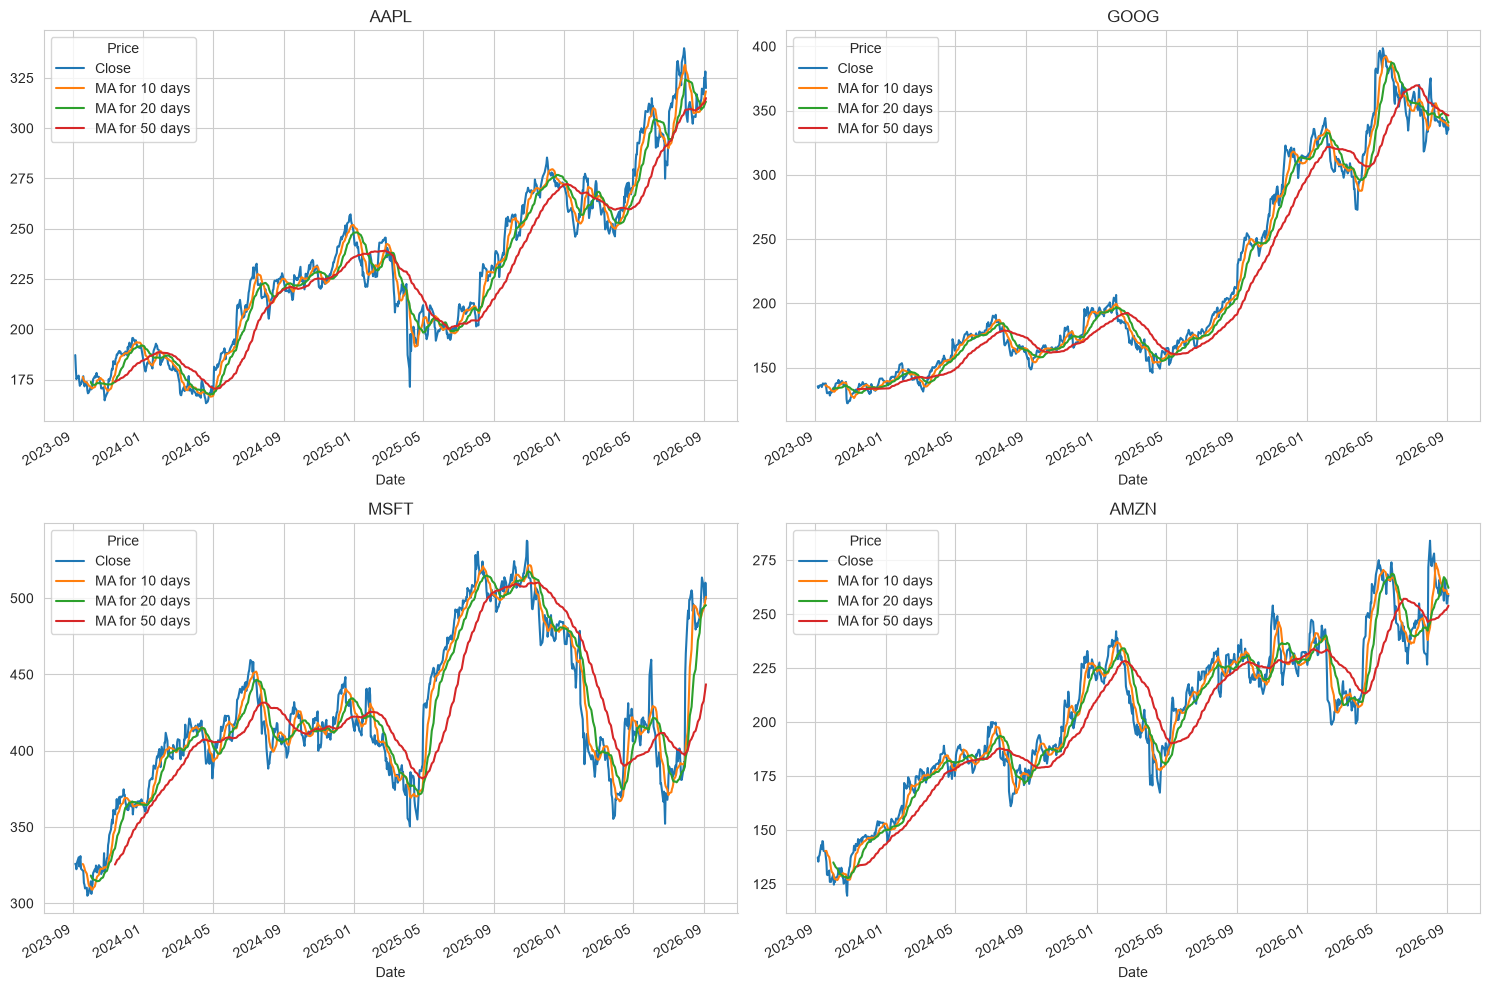

In [201]:
ma_day = [10, 20, 50]
for ma in ma_day:
    for company in company_list:
        company[f"MA for {ma} days"] = company['Close'].rolling(ma).mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for company, name, ax in zip(company_list, tech_list, axes.flatten()):
    company[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=ax)
    ax.set_title(name)
fig.tight_layout()
plt.show()

## 4. Daily Returns

Calculate the percentage change in closing price from one day to the next for each stock, and plot it over time to visualize daily volatility.

- `company['Close'].pct_change()`: calculates the day-over-day percentage change in price — this is the "daily return"

Plotting this (rather than raw price) shows how much each stock moves day-to-day, regardless of its absolute price level, making different stocks more directly comparable.

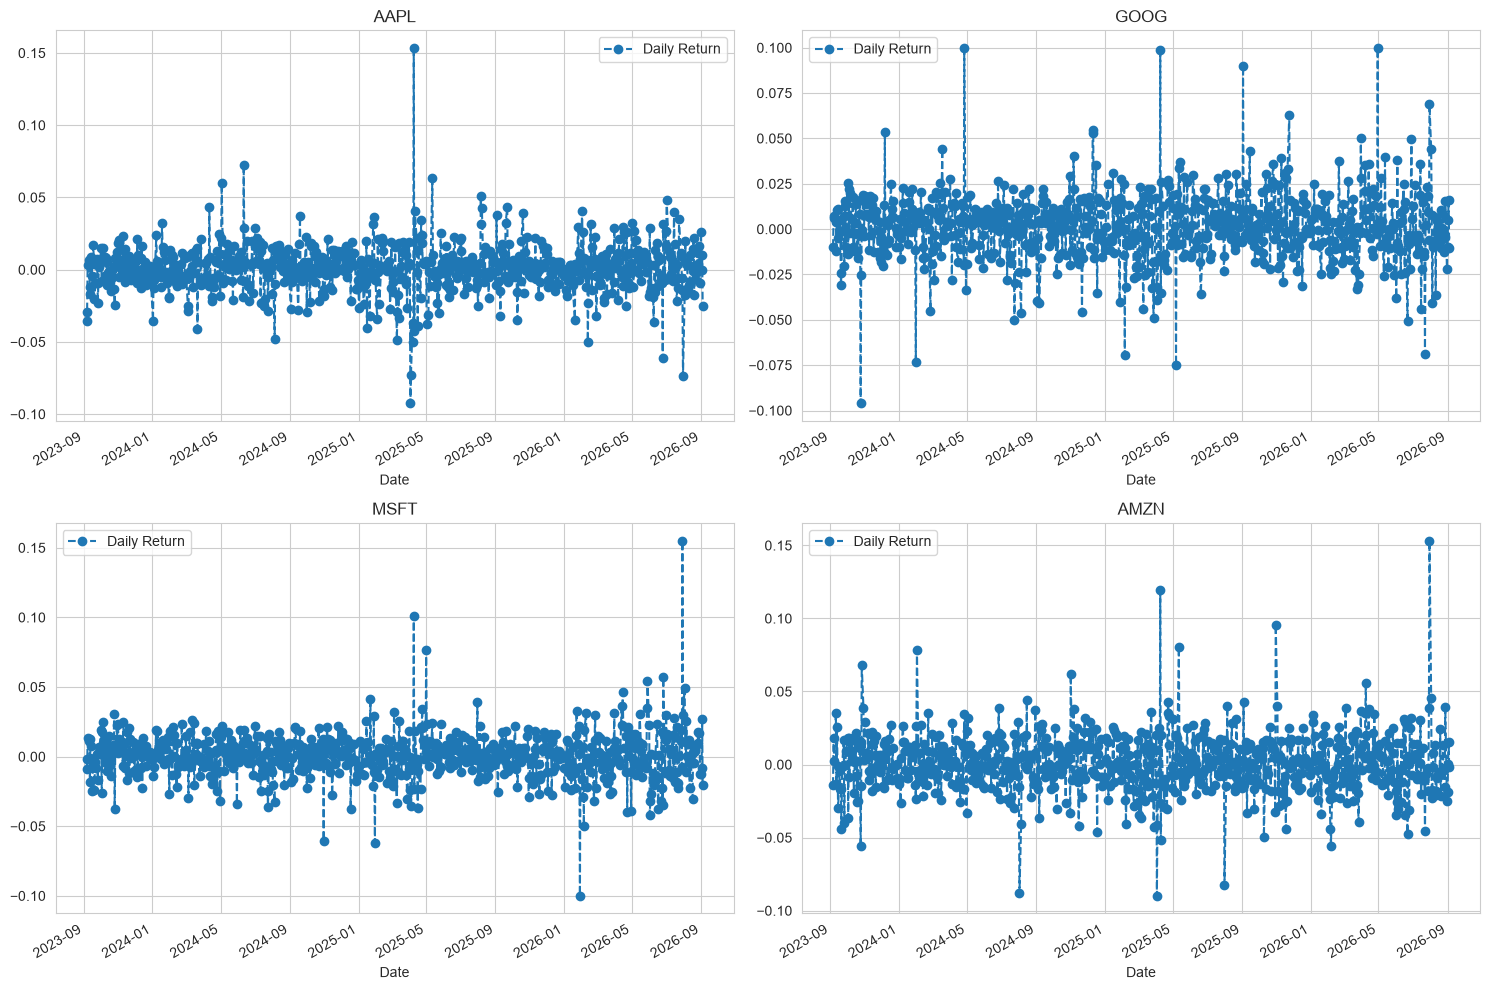

In [204]:
for company in company_list:
    company['Daily Return'] = company['Close'].pct_change()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for company, name, ax in zip(company_list, tech_list, axes.flatten()):
    company['Daily Return'].plot(ax=ax, legend=True, linestyle='--', marker='o')
    ax.set_title(name)
fig.tight_layout()
plt.show()

## 5. Correlation Between Stocks

Combine the closing prices of all 4 stocks into one table, calculate their daily returns, and visualize how closely each stock's returns move in relation to the others.

- `yf.download(tech_list, ...)['Close']`: downloads closing prices for all 4 tickers into a single combined table
- `closing_df.pct_change()`: calculates daily returns for each stock, so their movements can be directly compared
- `sns.pairplot(...)`: creates a grid of scatter plots comparing every pair of stocks' daily returns, with a regression line — a visual way to spot which stocks tend to move together
- `sns.heatmap(tech_rets.corr(), annot=True)`: computes the exact correlation coefficient (between -1 and +1) between every pair of stocks, displayed as a color-coded grid — a stronger color/higher number means the stocks tend to move together more closely

[*********************100%***********************]  4 of 4 completed


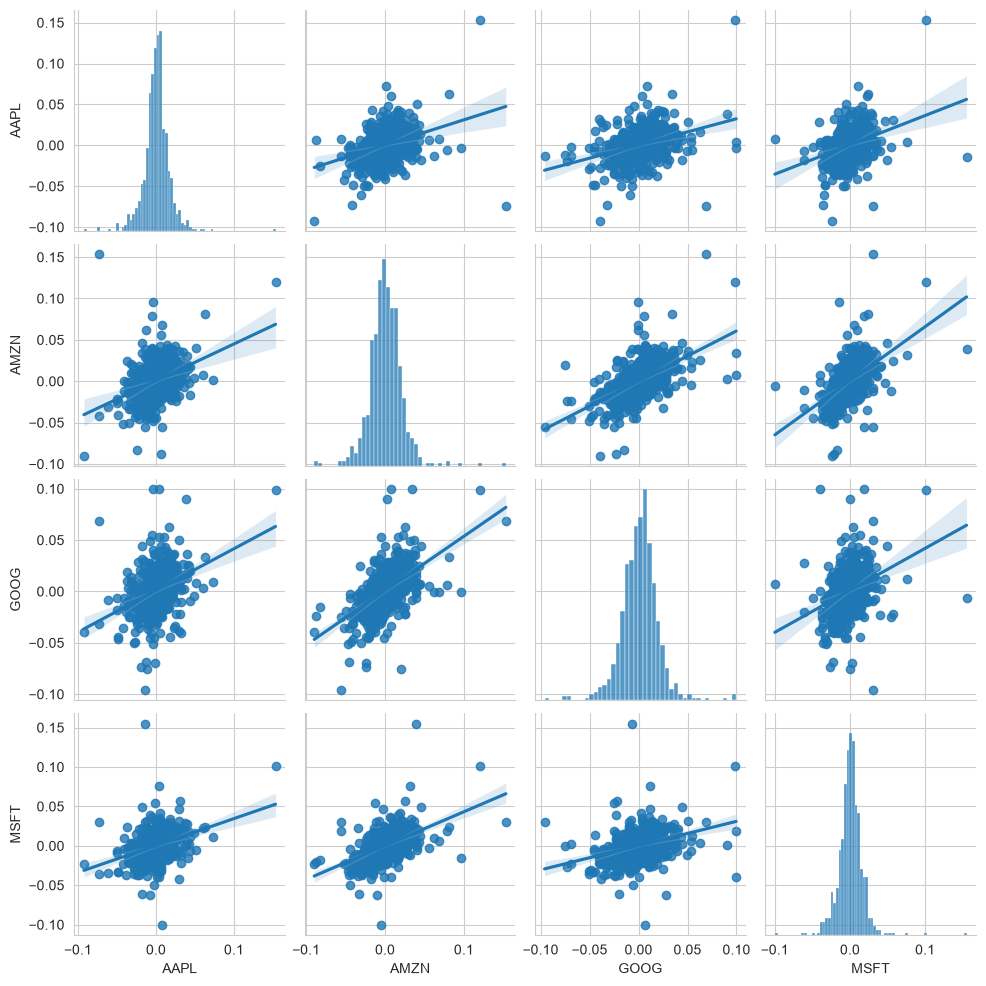

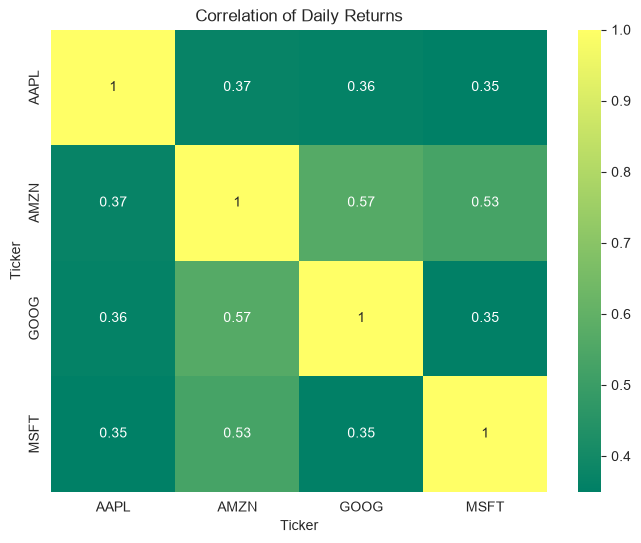

In [206]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']
tech_rets = closing_df.pct_change()

sns.pairplot(tech_rets.dropna(), kind='reg')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of Daily Returns')
plt.show()

## 6. Risk vs. Expected Return

Plot each stock's average daily return (expected return) against the volatility of its returns (risk), to visually compare which stocks offer higher reward relative to their risk.

- `rets.mean()`: the average daily return for each stock — a simple measure of "expected return"
- `rets.std()`: the standard deviation of daily returns for each stock — a common measure of volatility/"risk" (higher = more unpredictable day-to-day swings)
- `plt.scatter(...)`: plots each stock as a point, with expected return on the x-axis and risk on the y-axis
- `plt.annotate(...)`: labels each point with its ticker symbol

Ideally, you want stocks positioned toward the bottom-right (high return, low risk).

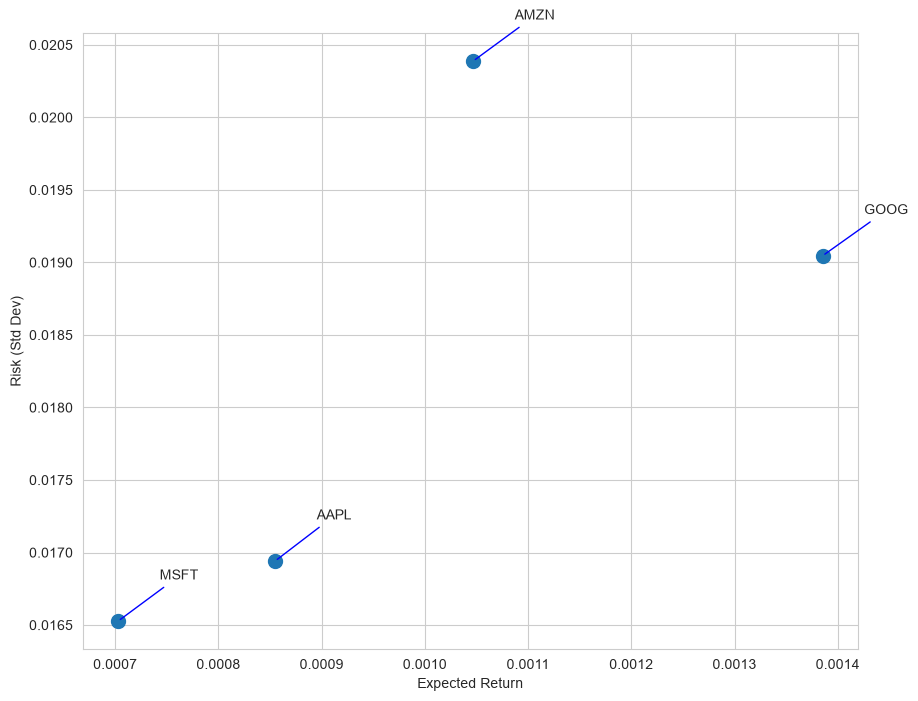

In [209]:
rets = tech_rets.dropna()

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=100)
plt.xlabel('Expected Return')
plt.ylabel('Risk (Std Dev)')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(30, 30), textcoords='offset points',
                 arrowprops=dict(arrowstyle='-', color='blue'))
plt.show()

# 3.Preprocessing

In [13]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])

In [14]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.740689
2020-01-03,-1.752401
2020-01-06,-1.742895
2020-01-07,-1.748550
2020-01-08,-1.729299
...,...
2026-08-31,2.336060
2026-09-01,2.474075
2026-09-02,2.471241


## Building Sequences

Create overlapping 30-day sequences from the closing price data using a sliding window. Each sequence represents 30 consecutive days of prices, which the LSTM will use to learn patterns over time rather than looking at single days in isolation.

- Chunk 1 covers days 1–30
- Chunk 2 covers days 2–31
- Chunk 3 covers days 3–32
- ...and so on


In [112]:
seq_length = 30      # This step builds the sequences the LSTM will actually learn from.   
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)



# 4.Train/Test Split


Split the sequences into training (80%) and testing (20%) sets. For each 30-day sequence, use the first 29 days as the input (X) and the 30th day as the target (y) the model is trying to predict. This structure teaches the model to predict the next day's price based on the recent price history.

In [115]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)


# 5.Building and Training The Model


## Model Architecture: LSTM Prediction Model

This defines the neural network used to predict the next day's closing price.

The model has two main parts:
- **LSTM layer** — reads through the sequence of past days (29 days of Close prices) and builds up an internal understanding of the pattern over time.
- **Linear layer** — takes the LSTM's final understanding and converts it into a single predicted value (the next day's price).

### `__init__` method
Sets up the model's components:
- `input_dim`: number of features per day (1, since we only use Close price)
- `hidden_dim`: size of the LSTM's internal memory (controls how much pattern complexity it can capture)
- `num_layers`: number of stacked LSTM layers
- `output_dim`: number of values to predict (1, the next day's price)

### `forward` method
Defines how data flows through the model:
1. Initialize the LSTM's hidden state (`h0`) and cell state (`c0`) as zeros, since there's no prior memory at the start of each sequence.
2. Pass the input sequence through the LSTM, which processes the 29 days one at a time and updates its internal memory as it goes.
3. Take only the LSTM's output from the final time step (after it has seen the full sequence), since this represents its complete understanding of the pattern.
4. Pass that final output through the Linear layer to produce a single predicted price.


In [120]:

class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

## Creating the Model, Loss Function, and Optimizer


### Instantiating the model

This creates an actual instance of the `PredictionModel` class using specific settings:
- `input_dim=1`: each day has 1 feature (Close price)
- `hidden_dim=32`: size of the LSTM's internal memory
- `num_layers=2`: number of stacked LSTM layers
- `output_dim=1`: predicts a single value (next day's price)
- `.to(device)`: moves the model onto the GPU or CPU

In [125]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

### Loss function

Defines how the model's error is measured. Mean Squared Error (MSE) calculates the squared difference between predicted and actual prices, penalizing larger mistakes more heavily. Lower MSE means better predictions.


In [129]:
criterion = nn.MSELoss()


### Optimizer

Defines how the model's weights are updated during training.
- `Adam`: a widely-used optimization algorithm for training neural networks
- `model.parameters()`: the model's learnable weights that the optimizer is allowed to adjust
- `lr=0.01`: the learning rate, controlling how large each adjustment step is

In [133]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

## Training the Model

This is the training loop — the step where the model actually learns from the data.

**`num_epochs = 200`**
An epoch is one full pass through the entire training set. The model will see all the training data 200 times, gradually improving its predictions with each pass.

**Steps inside each epoch:**
1. **Predict** — run all training sequences through the model to get its current guesses (`y_train_pred`).
2. **Measure error** — compare the guesses to the actual values (`y_train`) using the loss function (MSE), producing a single number representing how wrong the predictions were.
3. **Log progress** — every 25 epochs, print the current loss to track improvement over time.
4. **Reset gradients** — clear out gradients from the previous loop (`optimizer.zero_grad()`), since PyTorch accumulates them by default.
5. **Backpropagate and update** — `loss.backward()` calculates how each internal weight contributed to the error, and `optimizer.step()` adjusts the weights slightly to reduce that error.

By the end of training, the loss value should be noticeably lower than at the start, indicating the model has learned patterns from the training data.

In [ ]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

## 6.Evaluating the Model
### Generating Predictions


First, Switch the model to evaluation mode and generate predictions on the test set, then convert all predictions and actual values back into real price scale.


- `model.eval()`: switches the model into evaluation mode, signaling that training is done and it should now be used purely for making predictions.
- `y_test_pred = model(X_test)`: runs the test data (the 20% the model never trained on) through the model to get its predictions.
- `.detach()`: removes the tensor from PyTorch's gradient tracking, since gradients are no longer needed at this stage.
- `.cpu()`: moves the tensor from GPU to CPU, since NumPy can only operate on CPU data.
- `.numpy()`: converts the PyTorch tensor into a NumPy array.
- `scaler.inverse_transform(...)`: reverses the earlier scaling step, converting the model's scaled outputs back into real dollar price values.

This is done for both training and test predictions/actuals, so the model's performance can be compared directly in real price terms — showing how well it fits data it trained on, and more importantly, data it has never seen.

In [141]:
model.eval()
y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

### Evaluating with RMSE

- `y_train[:, 0]` / `y_train_pred[:, 0]`: extract the actual and predicted prices as plain 1D arrays (since there's only one feature — Close price).
- `root_mean_squared_error(actual, predicted)`: calculates the average prediction error in the original price scale (dollars).

**Result:**
- `train_rmse ≈ $3.17` — average error on training data
- `test_rmse ≈ $6.03` — average error on test data (unseen by the model)

Note: A smaller gap between train and test RMSE suggests the model is generalizing reasonably well, rather than overfitting to the training data.

In [145]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [147]:
train_rmse

3.174401044845581

In [149]:
test_rmse

6.035467624664307

## Why RMSE Instead of MSE for Evaluation

- **MSE** is used during training because it's better behaved mathematically for the optimizer to work with.
- **RMSE** is used after training, for reporting/evaluating results, because it's in the same units as the actual data (dollars) and is much easier to interpret.

# 7.Visualization

## Visualizing Predictions vs Actual Prices

Create a figure with two stacked charts: the top chart compares actual vs. predicted prices over the test period, and the bottom chart shows the day-by-day prediction error alongside the overall RMSE.



- **Top chart**: plots the actual closing prices (blue) against the model's predicted prices (green) for the test period, using the matching dates pulled from the original dataframe.
- **Bottom chart**: plots the daily absolute prediction error (red) alongside a dashed horizontal line marking the overall test RMSE, making it easy to spot which days had better or worse-than-average predictions.
- `plt.tight_layout()` ensures both charts are neatly spaced without overlapping labels.

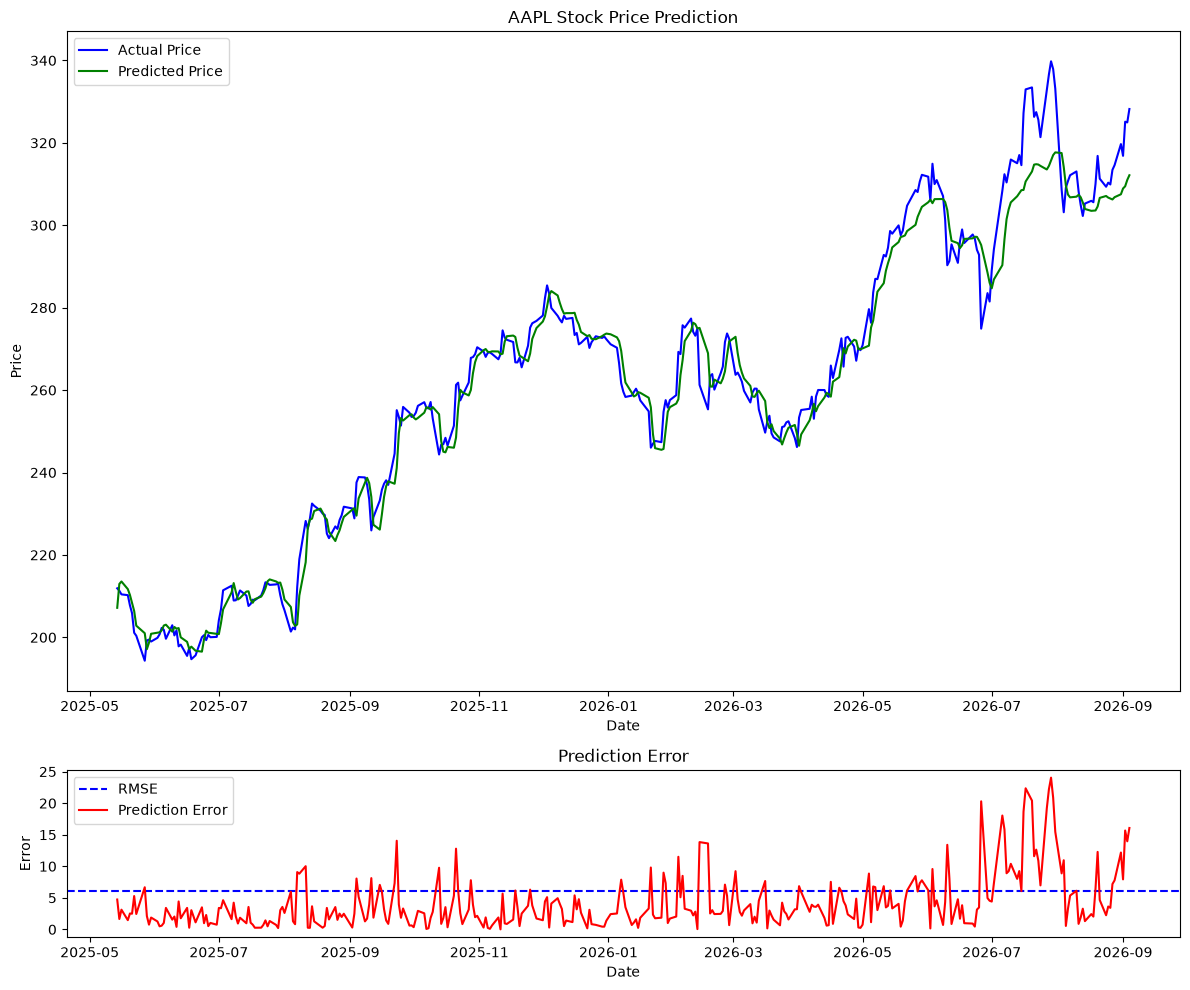

In [160]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()

## 8.Insights & Conclusion

The model's predicted prices closely track the actual AAPL closing prices for most of the test period (May 2025 – June 2026), successfully capturing the general trend and short-term fluctuations.

However, looking at the prediction error chart reveals an important pattern:
- From May 2025 to around June 2026, the daily prediction error stays mostly **below** the average RMSE line, indicating strong performance during this calmer, gradually trending period.
- From around June 2026 onward, the error spikes sharply, well above the RMSE line. This coincides with a period where the actual price surges upward more sharply and becomes more volatile — the model's predictions lag behind and fail to keep pace with this new behavior.

**Key takeaway:** The LSTM model learned the historical patterns in the training data well, but struggled to anticipate a sudden, unprecedented shift in price behavior it hadn't seen before. This highlights a core limitation of pattern-based prediction models — they are good at describing patterns similar to what they've already seen, but are unreliable when the market behaves in new or unexpected ways.

This reinforces why models like this should be treated as a learning exercise in time series forecasting and deep learning, rather than a tool for actual financial decision-making.